In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("customer_shopping_behavior.csv",encoding="latin1",lineterminator="\n")

# Data preprocessing

In [6]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases\r
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly\r
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly\r
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly\r
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually\r
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly\r


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer ID              5050 non-null   int64  
 1   Age                      5050 non-null   int64  
 2   Gender                   5050 non-null   object 
 3   Item Purchased           5050 non-null   object 
 4   Category                 5050 non-null   object 
 5   Purchase Amount (USD)    4494 non-null   float64
 6   Location                 5050 non-null   object 
 7   Size                     4680 non-null   object 
 8   Color                    5050 non-null   object 
 9   Season                   5050 non-null   object 
 10  Review Rating            4449 non-null   float64
 11  Subscription Status      5050 non-null   object 
 12  Shipping Type            5050 non-null   object 
 13  Discount Applied         5050 non-null   object 
 14  Previous Purchases      

In [10]:
df.duplicated().sum()

np.int64(50)

``To remove duplicate``
rows identified by df.duplicated().sum(), use df.drop_duplicates(inplace=True). This method drops all rows that have identical values across all columns, keeping the first occurrence by default.

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

**sucessfully removed duplicate rows**

**categorizing Review Rating column**
we should cut the 'Review Rating' and make 4 categories: `popular` `average` `below_avg` `not_popular` to describe it more clearly and we using catigorize_col() fuction provided above.  **not_popular below 25%** , **below_avg between 50% to 25%** ,**average between 75% to 50%** , **popular above 75%**

In [26]:
def categoring_col(df,col,labels):
    edges = [df[col].describe()['min'],
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    df[col] = pd.cut(df[col] , edges , labels=labels , duplicates='drop' )
    return df
    

In [27]:
labels = ['not_popular','below_avg','average','popular']
categoring_col(df,'Review Rating',labels)
df['Review Rating'].unique()

['below_avg', 'average', 'not_popular', 'popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [28]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases\r
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,below_avg,No,Standard,No,36.0,Cash,Weekly\r
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,average,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly\r
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,below_avg,No,2-Day Shipping,No,18.0,Cash,Monthly\r
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,average,No,Store Pickup,No,25.0,Cash,Annually\r
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,below_avg,No,Store Pickup,No,17.0,Credit Card,Weekly\r


**now moving to handle missing value**

Review rating depends  over the Item purchsed by using df.fillna() function

Purchase Amount (USD) depends  over the Item purchsed ,discount applied by using df.fillna() function


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Customer ID              5000 non-null   int64   
 1   Age                      5000 non-null   int64   
 2   Gender                   5000 non-null   object  
 3   Item Purchased           5000 non-null   object  
 4   Category                 5000 non-null   object  
 5   Purchase Amount (USD)    5000 non-null   float64 
 6   Location                 5000 non-null   object  
 7   Size                     4630 non-null   object  
 8   Color                    5000 non-null   object  
 9   Season                   5000 non-null   object  
 10  Review Rating            5000 non-null   category
 11  Subscription Status      5000 non-null   object  
 12  Shipping Type            5000 non-null   object  
 13  Discount Applied         5000 non-null   object  
 14  Previous Purc

In [41]:
df['Review Rating'] = df['Review Rating'].fillna(
    df.groupby('Item Purchased')['Review Rating'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)

df['Purchase Amount (USD)'] = df['Purchase Amount (USD)'].fillna(
    df.groupby(['Item Purchased','Discount Applied'])['Purchase Amount (USD)'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)
df.dropna(axis=0,inplace=True)
print(df['Size'].isna().sum())
print(df['Purchase Amount (USD)'].isna().sum())
print(df['Review Rating'].isna().sum())

0
0
0


# removing unnessary columns like
``Previous Purchases``  ``Payment Method`` ``Subscription Status`` ``Frequency of Purchases\r``

In [45]:
cols = ['Previous Purchases','Payment Method','Subscription Status','Frequency of Purchases\r']
df.drop(cols,axis=1,inplace=True)
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Shipping Type', 'Discount Applied'],
      dtype='object')

In [47]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Discount Applied
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,below_avg,Standard,No
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,average,Free Shipping,Yes
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,below_avg,2-Day Shipping,No
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,average,Store Pickup,No
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,below_avg,Store Pickup,No


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4267 entries, 0 to 5049
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Customer ID            4267 non-null   int64   
 1   Age                    4267 non-null   int64   
 2   Gender                 4267 non-null   object  
 3   Item Purchased         4267 non-null   object  
 4   Category               4267 non-null   object  
 5   Purchase Amount (USD)  4267 non-null   float64 
 6   Location               4267 non-null   object  
 7   Size                   4267 non-null   object  
 8   Color                  4267 non-null   object  
 9   Season                 4267 non-null   object  
 10  Review Rating          4267 non-null   category
 11  Shipping Type          4267 non-null   object  
 12  Discount Applied       4267 non-null   object  
dtypes: category(1), float64(1), int64(2), object(9)
memory usage: 437.7+ KB


In [49]:
df.nunique()

Customer ID              4267
Age                        53
Gender                      3
Item Purchased             30
Category                    4
Purchase Amount (USD)     276
Location                   54
Size                        4
Color                      25
Season                      5
Review Rating               4
Shipping Type               6
Discount Applied            2
dtype: int64

**now data is completely preprossed and ready to use for finding insights**

# Data visualization

# Which specific Item Purchased has the highest average Review Rating?

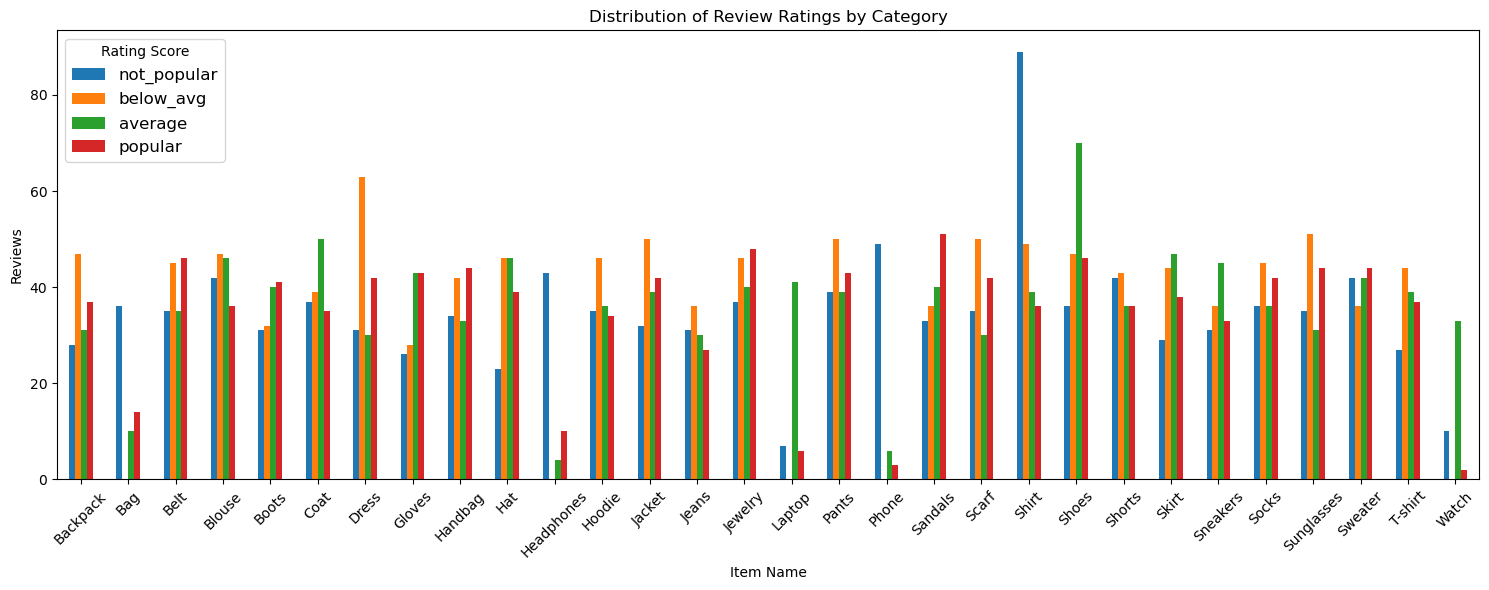

In [64]:
rating_counts = df.groupby('Item Purchased')['Review Rating'].value_counts().unstack()

rating_counts.plot(kind='bar', figsize=(15, 6))

plt.title('Distribution of Review Ratings by Category')
plt.xlabel('Item Name')
plt.ylabel('Reviews')
plt.legend(title='Rating Score',loc='upper left',fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
popular_items = df[df['Review Rating'] == 'popular']['Item Purchased'].value_counts()
#top 5 popular items
print(popular_items[0:5])

Item Purchased
Sandals    51
Jewelry    48
Belt       46
Shoes      46
Sweater    44
Name: count, dtype: int64


# Which Category has most expensive item?

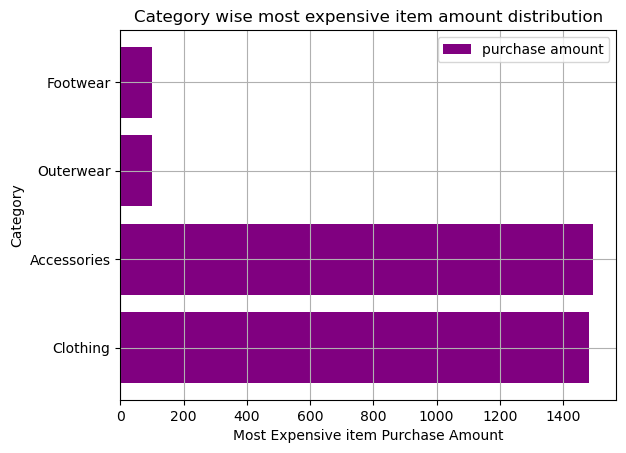

In [84]:
plt.barh(df['Category'],df['Purchase Amount (USD)'],color='purple',label='purchase amount')
plt.title("Category wise most expensive item amount distribution")
plt.xlabel("Most Expensive item Purchase Amount")
plt.ylabel("Category")
plt.grid()
plt.legend()
plt.show()

In [82]:
expensive_item = df[df['Purchase Amount (USD)'] == df['Purchase Amount (USD)'].max()][['Item Purchased', 'Category','Purchase Amount (USD)']]
print(expensive_item)

     Item Purchased     Category  Purchase Amount (USD)
1323     Headphones  Accessories                1493.56


# Which Category has generated the highest total revenue (sum of Purchase Amount (USD))?

In [86]:
total_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum()
print(total_revenue)

Category
Accessories    150656.01
Clothing       178914.38
Footwear        36093.00
Outerwear       18524.00
Name: Purchase Amount (USD), dtype: float64


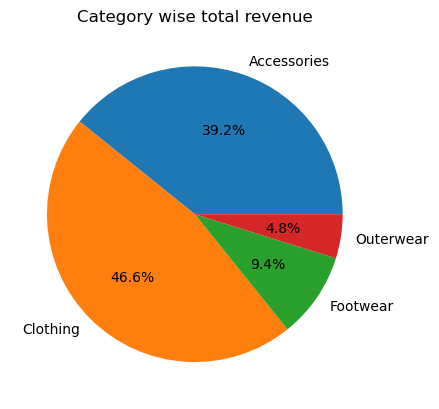

In [95]:
total_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum()
plt.pie(total_revenue,labels=total_revenue.index,autopct='%1.1f%%')
plt.title("Category wise total revenue")
plt.show()

# What is the distribution of product categories purchased by each gender?

**crosstab used to find frequencies not for sum() as groupby**

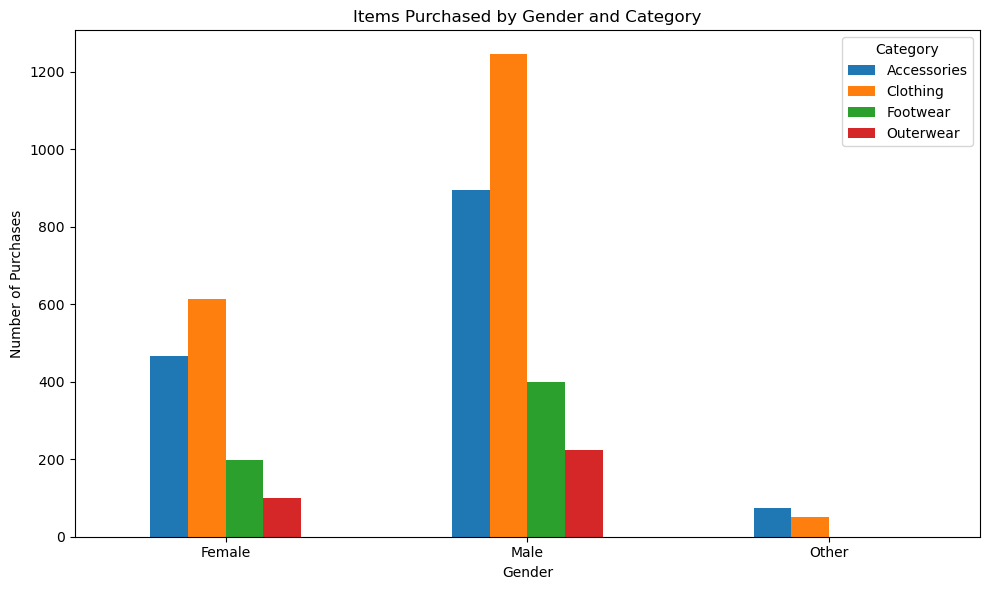

In [99]:
gender_buying_habits = pd.crosstab(df['Gender'], df['Category'])
gender_buying_habits.plot(kind='bar', figsize=(10, 6))

plt.title('Items Purchased by Gender and Category')
plt.xlabel('Gender')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [91]:
print(gender_buying_habits)

Category  Accessories  Clothing  Footwear  Outerwear
Gender                                              
Female            467       613       199        101
Male              894      1245       400        223
Other              74        51         0          0


# Identify the Item Purchased that appears the most frequently in the dataset (highest count) and its rating?

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Discount Applied
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,below_avg,Standard,No
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,average,Free Shipping,Yes
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,below_avg,2-Day Shipping,No
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,average,Store Pickup,No
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,below_avg,Store Pickup,No


In [112]:
frequent_item_name = df['Item Purchased'].mode()[0]

frequent_item = df[df['Item Purchased'] == frequent_item_name][['Item Purchased', 'Review Rating', 'Category']]

frequent_item['frequency'] = len(frequent_item)

review_counts = frequent_item['Review Rating'].value_counts()

print("--- Item Details with Total Frequency ---")
print(frequent_item.head()) 
print("\n--- Review Rating Breakdown for this Item ---")
print(review_counts)

--- Item Details with Total Frequency ---
   Item Purchased Review Rating     Category  frequency
2           Shirt     below_avg     Clothing        213
15          Shirt       average     Clothing        213
28          Shirt   not_popular     Clothing        213
65          Shirt   not_popular     Clothing        213
69          Shirt   not_popular  Accessories        213

--- Review Rating Breakdown for this Item ---
Review Rating
not_popular    89
below_avg      49
average        39
popular        36
Name: count, dtype: int64


# For gender wise, what is the most popular Color for each?

In [127]:
most_popular_colors = df.groupby('Gender')['Color'].agg(lambda x: x.value_counts().idxmax())

print(most_popular_colors)

Gender
Female    Black
Male      Black
Other      Blue
Name: Color, dtype: object


# Summary

# Which specific Item Purchased has the highest average Review Rating?
**`Sandals` is the item with the highest average review rating, having approximately `7.9%` higher rating compared to other top-rated products.**

# Which Category has most expensive item?
**`Accessories` is the category with the most expensive item, where `Headphones` cost around `1493.56 USD`.**

# Which Category has generated the highest total revenue (sum of Purchase Amount (USD))?
**`Clothing` category has generated the highest total revenue, contributing approximately `46.6%` of the total revenue.**

# What is the distribution of product categories purchased by each gender?
**Approximately `65%` of the buyers are male customers.**

**Accessories:** `33% female, 62% male, 5% others`  
**Clothing:** `32% female, 65% male, 3% others`  
**Footwear:** `33% female, 67% male`  
**Outerwear:** `31% female, 69% male`

# Identify the Item Purchased that appears the most frequently in the dataset (highest count) and its rating?
**`Shirt` is the most frequently purchased item; however, around `42%` of its reviews are low-rated, indicating lower customer satisfaction despite high sales.**

# For gender wise, what is the most popular Color for each?
**For both `Male` and `Female` customers, the most popular color is `Black`, while for `Others`, the most preferred color is `Blue`.**